In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch import optim
from torch.utils.data import TensorDataset, DataLoader
import random

random.seed(10)
torch.manual_seed(10)

bike_data = pd.read_csv('bikeshare.csv')

print("first 5 rows: ")
print(bike_data.head(5))

y = bike_data['bikers']
x = bike_data.iloc[:, 1:]

n = x.shape[0]

print(f"{n} samples with {x.shape[1]} features.")


first 5 rows: 
   bikers  holiday  workingday  temp   atemp   hum  windspeed  clear  \
0      16        0           0  0.24  0.2879  0.81        0.0      1   
1      40        0           0  0.22  0.2727  0.80        0.0      1   
2      32        0           0  0.22  0.2727  0.80        0.0      1   
3      13        0           0  0.24  0.2879  0.75        0.0      1   
4       1        0           0  0.24  0.2879  0.75        0.0      1   

   cloudy/misty  heavy rain/snow  ...  Mon  Tues  Wed  Thurs  Fri  Sat  \
0             0                0  ...    0     0    0      0    0    1   
1             0                0  ...    0     0    0      0    0    1   
2             0                0  ...    0     0    0      0    0    1   
3             0                0  ...    0     0    0      0    0    1   
4             0                0  ...    0     0    0      0    0    1   

   Winter  Spring  Summer  Fall  
0       1       0       0     0  
1       1       0       0     0  
2    

In [3]:
x = x.to_numpy()
y = y.to_numpy()


ntrain = 2000
train_ixs = random.sample(range(n), ntrain)
test_ixs = list(set(range(n)) - set(train_ixs))

x_train = x[train_ixs]
y_train = y[train_ixs]
x_test = x[test_ixs]
y_test = y[test_ixs]

x_train_t = torch.tensor(x_train, dtype=torch.float32)
y_train_t = torch.tensor(y_train, dtype=torch.float32)

x_test_t = torch.tensor(x_test, dtype=torch.float32)

In [4]:
class NNet(nn.Module):
    def __init__(self, input_dim, hidden_dim):
        super(NNet, self).__init__()
        self.layer1 = nn.Linear(input_dim, hidden_dim)
        self.layer2 = nn.Linear(hidden_dim, 1) 

    def forward(self, x):
        x = self.layer1(x) 
        x = nn.ReLU()(x) 
        x = self.layer2(x).squeeze() 
        x = torch.exp(x) ## exponential activation to ensure positive values
        return x
    
def poisson_loss(y_pred, y_true):
    # Negative Poisson log-likelihood: minimize f(x) - y * log(f(x))
    return torch.mean(y_pred - y_true * torch.log(y_pred))
    

In [5]:
input_dim = x_train.shape[1]
hidden_dim = 10
model = NNet(input_dim, hidden_dim)

optimizer = optim.Adam(model.parameters(), lr=0.01)

epochs = 100

train_dataset = TensorDataset(x_train_t, y_train_t)
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)

for epoch in range(epochs):
    for x_batch, y_batch in train_loader:
        optimizer.zero_grad()       # clear gradients from previous step
        y_pred = model(x_batch)
        
        loss = poisson_loss(y_pred, y_batch)
        
        loss.backward()             # backpropagation
        optimizer.step() 
        



Neural net RMSE: 76.71507405555892
Baseline RMSE: 132.64275581385832


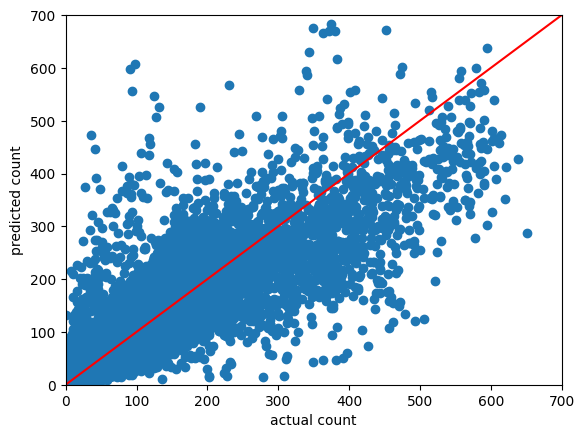

In [6]:


y_pred = model(x_test_t)
y_pred = y_pred.detach().numpy()

## compute RMSE
rmse = np.sqrt(np.mean((y_pred - y_test)**2))
print(f"Neural net RMSE: {rmse}")

baseline_pred = np.mean(y_train)
baseline_rmse = np.sqrt(np.mean((baseline_pred - y_test)**2))
print(f"Baseline RMSE: {baseline_rmse}")


## limit plot to [0, 700]
plt.xlim([0, 700])
plt.ylim([0, 700])
plt.xlabel("actual count")
plt.ylabel("predicted count")
plt.plot([0, 700], [0, 700], 'r')
plt.scatter(y_test, y_pred)
plt.show()